Set up SIR model:

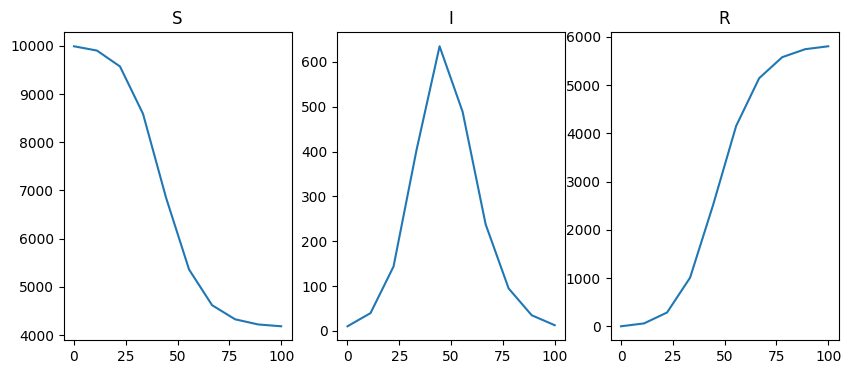

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygom import Event, Transition, SimulateOde


N = 10000
R0 = 1.5

# True values of unknown params
gamma = 1 / 4.0
beta = R0 * gamma / N

# Params and states
params=['beta', 'gamma']
states=['S', 'I', 'R']

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

event_list = [event_infection, event_recovery]
model = SimulateOde(state=states, param=params, event=event_list)
model.parameters = {"beta": beta, "gamma": gamma}

# Initial conditions
i0 = 10
y0 = np.array([N-i0, i0, 0])
model.initial_values = (y0, 0.0)

# Simulation to check:

t_eval = np.linspace(0, 100, 10)
sol = model.solve_deterministic(t_eval)
t = sol[0].result.t
y = sol[0].result.y
n_state = y.shape[1]

fig, axes = plt.subplots(1, n_state, figsize=(10, 4))

for i in range(n_state):
    axes[i].plot(t, y[:, i])
    axes[i].set_title(states[i])
plt.show()


Create loss object

In [2]:
from pygom import SquareLoss

# initial value
theta = np.array([beta*0.9, gamma*1.1])

loss = SquareLoss(
    theta=theta,
    ode=model,
    x0=y0,
    t0=t[0],
    t=t[1::],
    y=y[1::, 1:3],
    state_name=['I', 'R'])

Visualise cost function via grid calculation

This looks good, the minimum of the cost function is close to the true parameter values. Minimisation of the cost function should thus approach the true values.

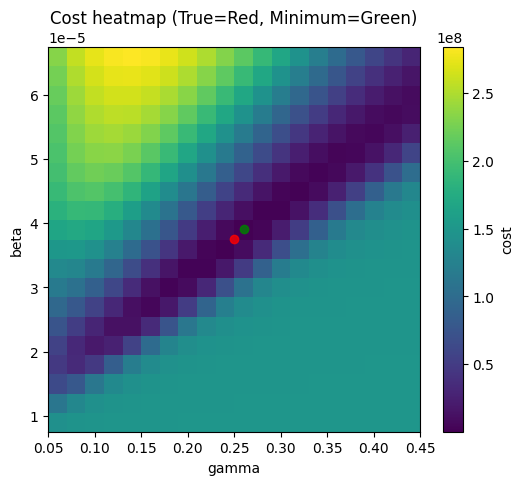

In [3]:
# Explore within 50% either side of true parameters
# Using 20 x 20 grid search 
interval = 0.8
n_breaks = 20
betas = np.linspace(beta*(1-interval), beta*(1+interval), n_breaks)
gammas = np.linspace(gamma*(1-interval), gamma*(1+interval), n_breaks)

# Container for cost values
z = np.zeros((len(betas), len(gammas)))

for i, beta_i in enumerate(betas):
    for j, gamma_j in enumerate(gammas):
        z[i, j] = loss.cost([beta_i, gamma_j])


plt.figure(figsize=(6, 5))
plt.imshow(
    z,
    extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
    origin='lower',
    aspect='auto'
)

plt.colorbar(label="cost")
plt.xlabel("gamma")
plt.ylabel("beta")
plt.title("Cost heatmap (True=Red, Minimum=Green)")
plt.scatter(gamma, beta, color="red", alpha=0.8)

i, j = np.unravel_index(np.argmin(z), z.shape)
plt.scatter(gammas[j], betas[i], color="green", alpha=0.8)

plt.show()

Now examine "sensitivity function" in the same way.

If I'm not mistaken, this should be the gradient of the cost function wrt the params - in which case, it's concerning that the true values are slightly offset from the vector field stationary point.

This is calculated via finite difference, so perhaps it is due to some forward distancing.

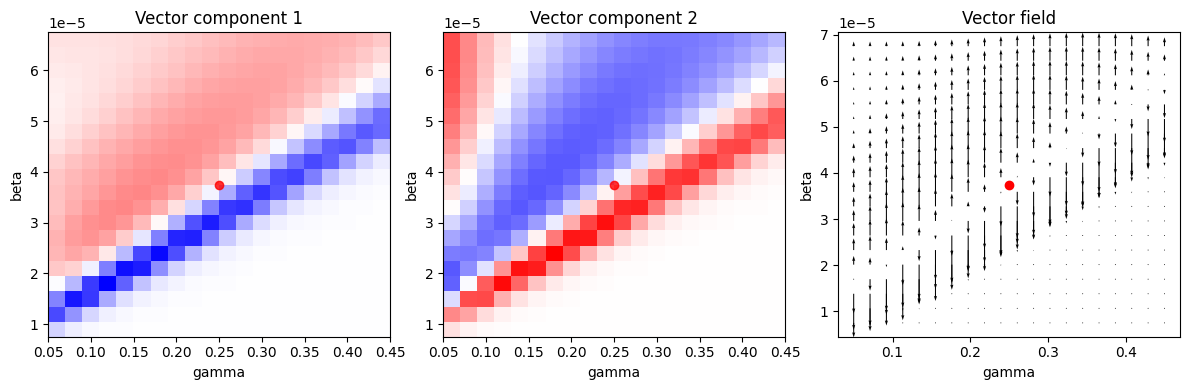

In [4]:
z0 = np.zeros((len(betas), len(gammas)))
z1 = np.zeros((len(betas), len(gammas)))

for i, beta_i in enumerate(betas):
    for j, gamma_j in enumerate(gammas):
        z0[i, j] = loss.sensitivity([beta_i, gamma_j])[0]
        z1[i, j] = loss.sensitivity([beta_i, gamma_j])[1]

z = [z0, z1]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(2):

    # Compute symmetric limits so colors are balanced
    vmax = np.abs(z[i]).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    im = axes[i].imshow(
        z[i],
        extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
        origin='lower',
        aspect='auto',
        cmap='bwr',          # blue-white-red
        norm=norm            # center at zero
    )

    axes[i].set_title(f"Vector component {i+1}")
    axes[i].set_xlabel("gamma")
    axes[i].set_ylabel("beta")
    axes[i].scatter(gamma, beta, color="red", alpha=0.8)

# Vector field
G, B = np.meshgrid(gammas, betas)
axes[2].quiver(G, B, z1, z0)
axes[2].set_xlabel("gamma")
axes[2].set_ylabel("beta")
axes[2].scatter(gamma, beta, color="red", zorder=3)
axes[2].set_title("Vector field")

plt.tight_layout()
plt.show()

Now we inspect the "adjoint". This function also obtains the gradient but via a different method.

NOTE: would be better to have something like: gradient(method = 'adjoint'), gradient(method = 'finite_diff')

The results below are concerning because:
1) They don't match the above (assuming this is intended to be same caculation but different method)
2) As before, the gradient does not push a solver towards the solution.

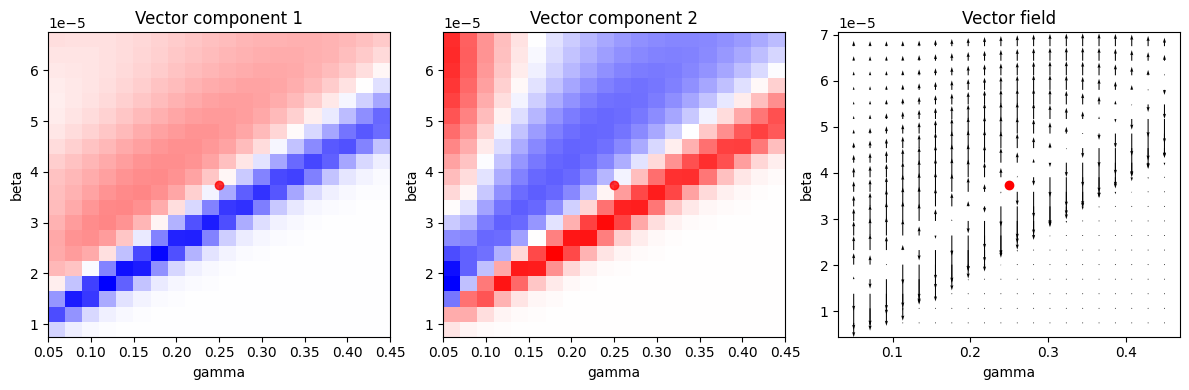

In [5]:
z0 = np.zeros((len(betas), len(gammas)))
z1 = np.zeros((len(betas), len(gammas)))

for i, beta_i in enumerate(betas):
    for j, gamma_j in enumerate(gammas):
        z0[i, j] = loss.adjoint([beta_i, gamma_j])[0]
        z1[i, j] = loss.adjoint([beta_i, gamma_j])[1]

z = [z0, z1]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(2):

    # Compute symmetric limits so colors are balanced
    vmax = np.abs(z[i]).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    im = axes[i].imshow(
        z[i],
        extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
        origin='lower',
        aspect='auto',
        cmap='bwr',          # blue-white-red
        norm=norm            # center at zero
    )

    axes[i].set_title(f"Vector component {i+1}")
    axes[i].set_xlabel("gamma")
    axes[i].set_ylabel("beta")
    axes[i].scatter(gamma, beta, color="red", alpha=0.8)

# Vector field
G, B = np.meshgrid(gammas, betas)
axes[2].quiver(G, B, z1, z0)
axes[2].set_xlabel("gamma")
axes[2].set_ylabel("beta")
axes[2].scatter(gamma, beta, color="red", zorder=3)
axes[2].set_title("Vector field")

plt.tight_layout()
plt.show()

To investigate:

model.sensitivity makes a call to model.jac which calls model._ode.ode_and_sensitivity_T and then sensitivity_T.

The latter two should probably join other mathematical methods in the maths classes.

Let's inspect integrateFuncJac and compare how it performs on the same integral we evaluated at the start of the notebook.

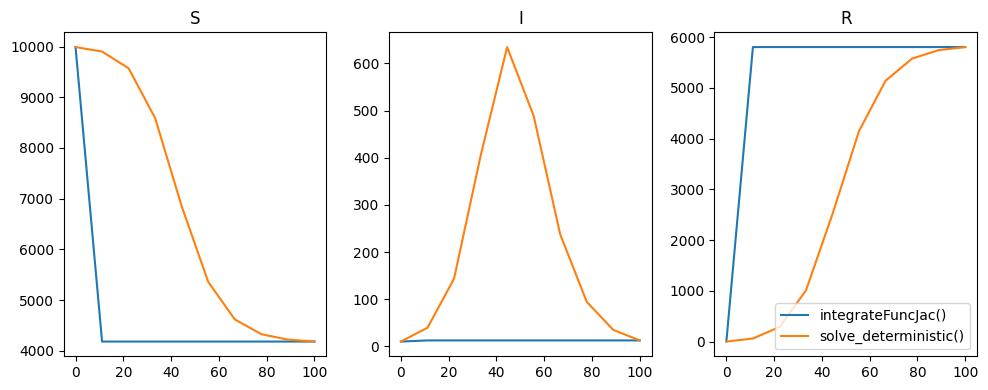

In [6]:
# Reset pygom model just to be sure


N = 10000
R0 = 1.5

# True values of unknown params
gamma = 1 / 4.0
beta = R0 * gamma / N

# Params and states
params=['beta', 'gamma']
states=['S', 'I', 'R']

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

event_list = [event_infection, event_recovery]
model = SimulateOde(state=states, param=params, event=event_list)
model.parameters = {"beta": beta, "gamma": gamma}

# Initial conditions
i0 = 10
y0 = np.array([N-i0, i0, 0])
model.initial_values = (y0, 0.0)

# Simulation to check:

t_eval = np.linspace(0, 100, 10)
sol = model.solve_deterministic(t_eval)
t = sol[0].result.t
y = sol[0].result.y
n_state = y.shape[1]


from pygom import ode_utils
from scipy.integrate import solve_ivp

out = ode_utils.integrateFuncJac(
    func=model.ode.T,
    jac=model.jacobian.T,
    x0=y0,
    t0=t_eval[0],
    t=t_eval[1::],
    includeOrigin=True,
    full_output=False)

sol = solve_ivp(
    fun = model.ode.T,
    t_span = (t_eval[0], t_eval[-1]),
    y0 = y0,
    jac = model.jacobian.T,
    t_eval = t,
    method = "LSODA"
)

fig, axes = plt.subplots(1, n_state, figsize=(10, 4))

for i in range(n_state):
    axes[i].plot(t, out[:, i], label="integrateFuncJac()")
    axes[i].plot(t, y[:, i], label="solve_deterministic()")
    # axes[i].plot(t, sol.y[i, :], label="solve_ivp()", linestyle="dashed")
    axes[i].set_title(states[i])
plt.legend()
plt.tight_layout()
plt.show()

# FitzHugh model fitting

The FH parameter estimation is still not getting to within 1%, as required by one of the tests.

The landscape local to the target is not super smooth, so maybe the minimiser is getting stuck.

We demonstrate by looking at a slice where we scan parameters a, b with c set to the target value.

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_28092\4060141177.py:41: RuntimeWarning: divide by zero encountered in log
  z[i, j] = np.log(loss.cost([a_i, b_j, c]))


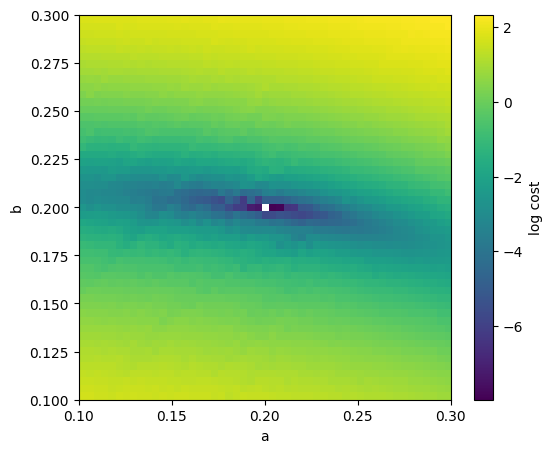

In [7]:
from pygom.model import common_models

a, b, c = 0.2, 0.2, 3.0

# initial values
y0 = [-1.0, 1.0]
target = np.array([a, b, c])
t = np.linspace(0, 20, 30).astype('float64')

# params
param_eval = [('a', a), ('b', b), ('c', c)]
model = common_models.FitzHugh(param_eval)
model.initial_values = (y0, t[0])
state_names = ['V', 'R']

out = model.solve_deterministic(t)
y = out[0].result.y

loss = SquareLoss(
    theta=[a, b, c],
    ode=model,
    x0=y0,
    t0=t[0],
    t=t[1::],
    y=y[1::, :],
    state_name=state_names)

# Explore within 50% either side of true parameters
# Using 20 x 20 grid search 
interval = 0.5
n_breaks = 51       # (odd number means we include the actual target params)
a_vals = np.linspace(a*(1-interval), a*(1+interval), n_breaks)
b_vals = np.linspace(b*(1-interval), b*(1+interval), n_breaks)
c_vals = np.linspace(c*(1-interval), c*(1+interval), n_breaks)

# Container for cost values
z = np.zeros((len(a_vals), len(b_vals)))

for i, a_i in enumerate(a_vals):
    for j, b_j in enumerate(b_vals):
        z[i, j] = np.log(loss.cost([a_i, b_j, c]))

plt.figure(figsize=(6, 5))
plt.imshow(
    z,
    extent=[
        a_vals.min(), a_vals.max(),
        b_vals.min(), b_vals.max()],
    origin='lower',
    aspect='auto'
)

plt.colorbar(label="log cost")
plt.xlabel("a")
plt.ylabel("b")
# plt.title("Cost heatmap (True=Red, Minimum=Green)")
# plt.scatter(a, b, 'o', color="red", alpha=0.8)

i, j = np.unravel_index(np.argmin(z), z.shape)
# plt.scatter(a_vals[j], b_vals[i], 'o', color="green", alpha=0.8)

plt.show()

Even though the parameters estimated for the FH model during the unittest are not all within 1%, it might not be so surprising.

This might be an unreasonable requirement given the (admittedly visual) similarity of the ODE solution using the target and estimated parameters as seen below (not the strong overlap obscuring the fact there are 2 sets of simulations)

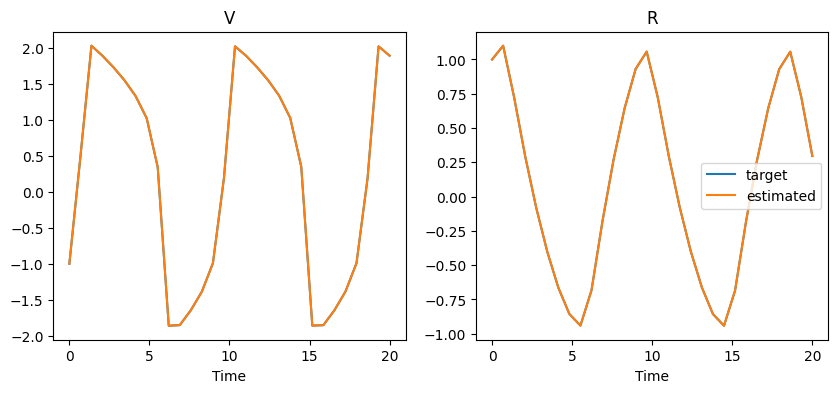

In [8]:
# Target values
tru_params = {
    'a': 0.2,
    'b': 0.2,
    'c': 3.0
}

# Estimated values during unittest
est_params = {
    'a': 0.20159333,
    'b': 0.21834306,
    'c': 2.99031094
}

param_sets = {
    'target': tru_params,
    'estimated': est_params
}

# initial values
y0 = [-1.0, 1.0]
t = np.linspace(0, 20, 30).astype('float64')

n_state = len(y0)
fig, axes = plt.subplots(1, n_state, figsize=(10, 4))

for param_type, params_eval in param_sets.items():
    model = common_models.FitzHugh(param_eval)
    model.initial_values = (y0, t[0])

    out = model.solve_deterministic(t)
    y = out[0].result.y

    for i in range(n_state):
        axes[i].plot(t, y[:, i], label=param_type)
        axes[i].set_title(state_names[i])
        axes[i].set_xlabel("Time")
plt.legend()
plt.show()